In [1]:
!pip install -q langchain_google_genai langgraph

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.7/70.7 kB 2.0 MB/s eta 0:00:00


**Ingresa el nombre completo de los integrantes del Grupo:**

* Barreto Lara, David
* Ñuflo Paucar, Stefano
* Rodrigo Alvarez, Meregildo
* Huanca Sancho, Yeimy Estephany
* Torres Valencia, Nicolas

## 💻 Caso:

La empresa Tech S.A. ha implementado un chatbot de consulta de procesos para su equipo de compras. El chatbot permite ingresar en lenguaje natural las consultas del equipo de compras para determinar si:

1.   El monto total de la compra requiere aprobación. Si la requiere, qué persona debería aprobar la compra. La política de aprobaciones es la siguiente:

>>>| Nivel de Aprobación | Monto de Compra | Aprobador / Responsable | Departamento |
>>>| :--- | :--- | :--- | :--- |
>>>|Aprobación automática| $\le S/.5,000$ | Sistema de Compras Automático | Compras |
>>>| Aprobación supervisor | $>S/.5,000$ y $\le S/.25,000$ | Ana M. Rodríguez | Supervisor de Compras |
>>>| Aprobación gerencial | $>S/.25,000$ USD | Carlos V. López | Gerencia General |


2.   El proveedor disponible para realizar la compra. En caso no se tuviera un proveedor listado, el chatbot indicará que se debe realizar una licitación. Para utilizar la política de proveedores primero debe clasificarse el producto o servicio en una de las categorías listadas, las cuales tienen un proveedor asignado:

>>> |Categoría | Razón social proveedor | Política de compra |
>>> | :--- | :--- | :--- |
>>> | **Infraestructura y Servidores** | InfraSolutions S.A. | **Directo** |
>>> | **Licenciamiento y Software** | SoftTools Latam | **Directo** |
>>> | **Consultoría y Servicios** | Servicios Globales G&C | **Directo**  |
>>> | **Material de Oficina (Bajo Valor)** | Office Stock Cía. | **Directo** |
>>> | **Marketing y Publicidad** | Agencia Creativa MKT | **Directo** |
>>> | **Otros** | Proveedor no listado | **Licitación** |

## 🏆 El reto:

Implementar el chatbot descrito, la solución debe presentar las siguientes características:

*   Debe realizarse con las herramientas de LangChain/LangGraph vistas en clase.
*   El chatbot debe utilizar la arquitectura ReAct.

>>>> 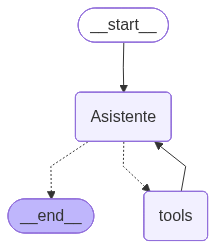
*   Se deben utilizar los modelos Gemini vistos en clase
*   La aplicación debe incluir el llamado de herramientas

In [2]:
# Número 01: Importa aquí las librerías adicionales que necesites

import os
import getpass
from IPython.display import Image, display

#Message state
from langgraph.graph.message import MessagesState

#Langchain mensajes
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage

#Langchain chat model (Google)
from langchain_google_genai import ChatGoogleGenerativeAI

#Herramientas
from langchain_core.tools import tool
from langchain_core.runnables.base import RunnableBinding

#Workflow
from langgraph.graph import StateGraph, START, END
from langgraph.graph.state import CompiledStateGraph
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

In [3]:
# NO MODIFICAR

# Ingresa la API KEY
os.environ["GOOGLE_API_KEY"]: str = getpass.getpass("Ingresa tu Google AI API key: ")

Ingresa tu Google AI API key: ··········


In [4]:
# Número 02: Inicializa el modelo

model: ChatGoogleGenerativeAI = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0)

In [5]:
# Número 03: Convierte estas funciones en herramientas (tools)

@tool
def obtener_aprobadores(monto_compra: float) -> str:
  """
  Determina el responsable de aprobar una compra basándose en el monto total.

  Contiene la política de límites de aprobación interna de la empresa.
  Los montos están expresados en soles (S/.).

  Args:
      monto_compra (float): El monto total de la solicitud de compra en soles (S/.).

  Returns:
      str: El nombre del responsable de la aprobación o el sistema automático (no requiere aprobación).
  """
  if monto_compra <= 5000:
    return "Sistema de Compras Automático"

  elif monto_compra > 5000 and monto_compra <= 25000:
    return "Ana M. Rodríguez"

  elif monto_compra > 25000:
    return "Carlos V. López"

@tool
def obtener_proveedor(categoria: str) -> str:
  """
  Identifica el nombre del proveedor basándose en la categoría del producto.

  Args:
      categoria (str): La categoría de producto (ej: 'Licenciamiento y Software').

  Returns:
      str: El nombre del proveedor asociado a la categoría, o la indicación
            "Requiere licitación" si el proveedor no está aprobado para compra directa.
  """

  if categoria == "Infraestructura y Servidores":
    return "InfraSolutions S.A."

  elif categoria == "Licenciamiento y Software":
    return "SoftTools Latam"

  elif categoria == "Consultoría y Servicios":
    return "Servicios Globales G&C"

  elif categoria == "Material de Oficina (Bajo Valor)":
    return "Office Stock Cía."

  elif categoria == "Marketing y Publicidad":
    return "Agencia Creativa MKT"

  else:
    return "Requiere licitación"

In [6]:
# Número 04: Enlaza las herramientas al modelo (binding)

tools: list = [obtener_aprobadores, obtener_proveedor]
modelo: RunnableBinding = model.bind_tools(tools)

In [7]:
# Número 05: Crea las indicaciones para tu chatbot (mensaje de sistema)

mensaje_sistema: SystemMessage = SystemMessage(
    "Eres el chatbot de consulta de procesos de compras de la empresa Tech S.A. "
    "Tu objetivo es ayudar al equipo de compras a determinar, para cada consulta, "
    "quién debe aprobar una compra y qué proveedor corresponde utilizar.\n\n"
    "Debes razonar paso a paso antes de usar una herramienta y explicar brevemente tu razonamiento:\n"
    "1. Si el usuario indica un monto de compra en soles (S/.), utiliza la herramienta "
    "'obtener_aprobadores' para identificar quién debe aprobar la compra.\n"
    "2. Si el usuario indica o se puede inferir la categoría del producto o servicio a comprar, "
    "utiliza la herramienta 'obtener_proveedor' para identificar el proveedor asignado. Las categorías "
    "válidas son: 'Infraestructura y Servidores', 'Licenciamiento y Software', 'Consultoría y Servicios', "
    "'Material de Oficina (Bajo Valor)' y 'Marketing y Publicidad'. Si el producto o servicio no encaja en "
    "ninguna de ellas, utiliza la categoría 'Otros'.\n"
    "3. Si falta información para clasificar el monto o la categoría, pide amablemente los datos que faltan "
    "antes de invocar las herramientas.\n"
    "4. Responde siempre en español, de forma clara y concisa, indicando el aprobador y/o el proveedor "
    "(o si se requiere licitación) según corresponda."
)

In [8]:
# Número 06: Crea tu asistente

class Estado(MessagesState): # NO MODIFICAR esta clase
    ...

def asistente(state: MessagesState) -> MessagesState:
  """
  Genera una respuesta del modelo usando el estado actual.

  Args:
      state (MessagesState): Mensajes previos del flujo.

  Returns:
      MessagesState: Nuevo estado con la respuesta generada.
  """
  prompt: SystemMessage = mensaje_sistema
  response: AIMessage = modelo.invoke([prompt] + state["messages"])
  return {"messages": [response]}

In [9]:
# Número 07: Crea el workflow React - El workflow debe tener la capacidad de llamar herramientas

workflow: StateGraph = StateGraph(Estado)
workflow.set_entry_point("Asistente")

#Nodo asistente
workflow.add_node("Asistente", asistente)

#Nodo Herramienta
tool_node: ToolNode = ToolNode(tools=tools) #Se define un nodo especial para el llamado de las herramientas
workflow.add_node("tools", tool_node)

#Condición: tools_condition permite identificar si se realizó una llamada a una herramienta
workflow.add_conditional_edges(
    "Asistente",
    tools_condition,
)

#Arquitectura ReAct: tras ejecutar la herramienta se regresa al asistente para razonar sobre el resultado
workflow.add_edge("tools", "Asistente")

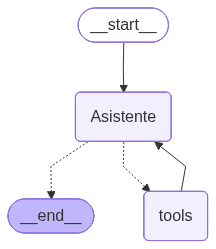

In [10]:
# Número 08: Compila tu workflow y muéstralo

workflow_compilado: CompiledStateGraph = workflow.compile()

display(Image(workflow_compilado.get_graph().draw_mermaid_png()))

In [11]:
# Número 09: Ingresa una pregunta y demuestra que el workflow funciona correctamente

mensaje = [HumanMessage(content="Necesito comprar licencias de software por un monto de S/. 8,000. ¿Quién debe aprobar la compra y qué proveedor debo usar?")]

messages = workflow_compilado.invoke({"messages": mensaje})

for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Necesito comprar licencias de software por un monto de S/. 8,000. ¿Quién debe aprobar la compra y qué proveedor debo usar?
================================== Ai Message ==================================

[{'type': 'text', 'text': 'Para la compra de licencias de software por S/. 8,000, primero determinaré quién debe aprobar la compra y luego qué proveedor utilizar.', 'extras': {'signature': 'CsoDARFNMg/qMRdKD18fEch5pEWGa43745T6K5FnNiay/33RKDZEM7iVunpSiGOJqupWydVKWwvE9k7BR5rqBA3lYfvvKGbqSP7Ay1zK5Zx2agQklRc+YbqHniZD4k1Qizk6t5xQujPkqo2vnTQr/8R9Qt3Q4QB1q2G4bDSDUSgWNdSepIHuByoces2qC+wA9E7jpto9KcLxT4fDQTGgohit39JyhVfoKp0+erywuRr+mtmEDrPLpIenFa3K5m9zEizY+V0ldbvvT/Iyx+pTgVsGBTBSG9WVNX9jidIHuv/kWhWkv1sgcnx1rtaDiClFgQFpd6mZ4kz3b+8kINeS9qhvspbopLN3uLpvuOeIbpfqDaMpqZBcbtBupQgBk35Uux5cIHlik5uap8xbvgrGu8nL/VF/S+VJmWaCkVXXAmEikcK8S6KOHT0a8eaesZIvuObGsOZUfevnpVoGyX5D2vbMoxI+HyfGMp2zla/d/xTvRMFBroIKywaHjpOFtwOqkLcJbW9q3aV

#### Pruebas adicionales del workflow

Se agregan dos casos más para cubrir el resto de la política de aprobaciones y de proveedores:

*   **Test 2:** monto bajo (aprobación automática) + categoría no listada (requiere licitación).
*   **Test 3:** monto alto (aprobación gerencial) + categoría con proveedor directo (Infraestructura y Servidores).

In [12]:
# Test 2: aprobación automática (monto bajo) + categoría no listada (requiere licitación)

mensaje_test2 = [HumanMessage(content="Quiero comprar merchandising para un evento interno por un monto de S/. 3,000. ¿Quién debe aprobar la compra y qué proveedor debo usar?")]

messages_test2 = workflow_compilado.invoke({"messages": mensaje_test2})

for m in messages_test2['messages']:
    m.pretty_print()

================================ Human Message =================================

Quiero comprar merchandising para un evento interno por un monto de S/. 3,000. ¿Quién debe aprobar la compra y qué proveedor debo usar?
================================== Ai Message ==================================

[{'type': 'text', 'text': 'Para determinar quién debe aprobar la compra y qué proveedor utilizar, necesito realizar dos consultas.\n\nPrimero, para la aprobación, usaré el monto de S/. 3,000.', 'extras': {'signature': 'CsAGARFNMg+LrXIq8w9DA2NvUri+8RZ69yNR/RYh9OmmATEetd9TrCkBcYDdsucH9pbQq2PnoH56NA+eFar4d2Rhz4YxjjzGfUa2HMo9YjU7AmlJiXK/OK8s+DwZ5v9K8wh6PeStsJtCr9I81lse/IjLnRPhF6eLMkBxKLr8agusbIwFaimH+JQzeNgjXQ6rKTdCZWKG5eqg/7wIJ1Toi/mNRJ7AqWw1835YCVKqpxnGhvUv0IHIXu1ynj7tLdbWpiniOj5I6bo6eV7nj2gJAbJabmNLo3Wc0imrcgz8YkjrJ7EXcMK7v7gm6LTAs33I8qNWJwalBcub8TTNVCDVMzuL3svtkR05HFi9M27JoiZRa+tpDrc17z2vXXCjSVPhxmDeUZkGtwi2c/hoPUL7nTlPWKfBkikeLj7TG65NvF7r7taL3LRZI0x99M13FQIP1yKOhhM6aOKa/c2DVEc0sk0mCbIDXVPHj

In [13]:
# Test 3: aprobación gerencial (monto alto) + categoría con proveedor directo (Infraestructura y Servidores)

mensaje_test3 = [HumanMessage(content="Necesito comprar servidores nuevos para el datacenter por un monto de S/. 40,000. ¿Quién debe aprobar la compra y qué proveedor debo usar?")]

messages_test3 = workflow_compilado.invoke({"messages": mensaje_test3})

for m in messages_test3['messages']:
    m.pretty_print()

================================ Human Message =================================

Necesito comprar servidores nuevos para el datacenter por un monto de S/. 40,000. ¿Quién debe aprobar la compra y qué proveedor debo usar?
================================== Ai Message ==================================

[{'type': 'text', 'text': 'Para determinar quién debe aprobar la compra y qué proveedor utilizar, necesito usar las herramientas disponibles.\n\nPrimero, para saber quién aprueba la compra, usaré el monto de S/. 40,000.', 'extras': {'signature': 'CosEARFNMg+qMWnSAzZKZ1bX6mckow9bRFj3wEONYVIoPRlcXYLUuuahMFjNhOvw5T12kGdO4FhdBigFKbbyH4QINJu8aj8EFncPWW8HKJ7vZg4gnURx78/npQ76yLfQf0Yi5k6XrVUWi81KDcd2IMTpwEvGabt1POMqTfkLtUOfgHkbu81ounjlzSKtJ5wSNPNmCNP/EnR3Y106CBPlNPFaezKMyaf/jrPkvsOwSPtJNhsUa9Zgp+e/Y+c9nYxMSDwmlwXXTT1UJGl/61Wf62FG6pqLVOSIg2x37arySA6olA3MfLbGABn9ISVvyhNzvssPklv8OrzeFT2jxuh5aidCaW496D9Y0hKFzOSWgq8hhQtpNJpkmWCLSl4REEO3n6c31XrKeviYOxnRcgm1KxjMuzcg2tSCxoQPgLCzWVPdIa0dsipYDiuBWnhzyZgSkg

In [14]:
# Test 4: categoria no listada (requiere licitacion)

mensaje_test4 = [HumanMessage(content="Necesito contratar un servicio de catering para la oficina por un monto de S/. 4,000. ¿Quién debe aprobar la compra y qué proveedor debo usar?")]

messages_test4 = workflow_compilado.invoke({"messages": mensaje_test4})

for m in messages_test4["messages"]:
    m.pretty_print()

================================ Human Message =================================

Necesito contratar un servicio de catering para la oficina por un monto de S/. 4,000. ¿Quién debe aprobar la compra y qué proveedor debo usar?
================================== Ai Message ==================================

[{'type': 'text', 'text': 'Para determinar quién debe aprobar la compra, utilizaré la herramienta `obtener_aprobadores` con el monto de S/. 4,000.\n\nPara identificar el proveedor, clasificaré "servicio de catering" en la categoría \'Otros\' y luego usaré la herramienta `obtener_proveedor`.', 'extras': {'signature': 'CuwFARFNMg+shEhTxiZZbcjiMUxkRtJWXgL/aFGlchSl4gFohWuqX/3Gmi7DpqL2d2Wt+z4jyTkWvNyLexHqRiNX0UozfeyxqJpvj5PiGcKAVCNfj8aSIfTszrdxUnkQwFYYiRudq1mUnvwa+WTYuEYXsuNClepFwrYkZo6Ari3SLW+UtNwXJjkOS130J0Fa74VCur72GA2z6YNGacYwswhEazBpgbHkjpyBmaRwnlAxApkAaEgITYgjMxC/DdDhbUyFYM5yWMiESFeqwNUVp++HczhKbD3uVfmZem5dRJiJgWKTrcfy1STzM/ncKsVkIEp1cYMb458JedIZQ0SSbVwSyR/YG/J4R4fo6KkxZHpmGmdGfCO+iD